# Deep Q Network with Cartpole

In [1]:
import torch
import torch.optim as optim
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import gymnasium as gym
import numpy as np

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [17]:
# Transition:
# (state, action, reward, next_state, done)

class ReplayBuffer:

    def __init__(self, max_size=1_000_000):
        self.buffer = []
        self.max_size = max_size
        self.ptr = 0

    def append(self, data):
        if len(self.buffer) == self.max_size:
            # Replace the oldest transition
            self.buffer[self.ptr] = data

            # Move pointer forward, wrapping around when necessary
            self.ptr = (self.ptr + 1) % self.max_size

        else:
            self.buffer.append(data)

    def __len__(self):
        return len(self.buffer)

    def sample(self, batch_size):
        indices = np.random.randint(
            0,
            len(self.buffer),
            size=batch_size
        )

        S, A, R, NS, D = [], [], [], [], []

        for idx in indices:
            s, a, r, ns, d = self.buffer[idx]

            S.append(s)
            A.append(a)
            R.append(r)
            NS.append(ns)
            D.append(d)

        return (
            np.array(S),
            np.array(A).reshape(-1, 1),
            np.array(R).reshape(-1, 1),
            np.array(NS),
            np.array(D).reshape(-1, 1)
        )

In [5]:
buffer = ReplayBuffer(max_size=5)

for i in range(1, 5):

    state = np.array([
        i,
        i + 1,
        i + 2,
        i + 3
    ])

    action = i % 2
    reward = float(i)
    next_state = state + 1
    done = False

    buffer.append(
        (state, action, reward, next_state, done)
    )

buffer.sample(2)

(array([[3, 4, 5, 6],
        [2, 3, 4, 5]]),
 array([[1],
        [0]]),
 array([[3.],
        [2.]]),
 array([[4, 5, 6, 7],
        [3, 4, 5, 6]]),
 array([[False],
        [False]]))

In [9]:
# Testing gym environment

env = gym.make('CartPole-v1')
print(env.action_space.n)
print(env.observation_space.shape[0])

2
4


In [10]:
class Network(nn.Module):
    def __init__(self, state_size, action_size, hidden_size):
        super().__init__()
        self.state_size = state_size
        self.action_size = action_size
        self.hidden_size = hidden_size
        self.layer1 = nn.Linear(self.state_size, self.hidden_size)
        self.layer2 = nn.Linear(self.hidden_size, self.hidden_size)
        self.output = nn.Linear(self.hidden_size, self.action_size)

    def forward(self, x):
        x = F.relu(self.layer1(x))
        x = F.relu(self.layer2(x))
        return self.output(x)

In [ ]:
class CartPoleAgent:
    def __init__(self, state_size, action_size, hidden_size, buffer_size, learning_rate):
        self.state_size = state_size
        self.action_size = action_size
        self.buffer_size = buffer_size
        self.replay_buffer = ReplayBuffer(buffer_size)
        self.main_network = Network(state_size, action_size, hidden_size).to(device)
        self.target_network = Network(state_size, action_size, hidden_size).to(device)
        self.target_network.load_state_dict(self.main_network.state_dict())
        self.target_network.eval()
        self.optimizer = optim.Adam(self.main_network.parameters(), lr=learning_rate)

    def select_action(self, state, epsilon):
        if np.random.uniform(0, 1) < epsilon:
            # explore
            action = np.random.randint(self.action_size)
        else:
            # exploit
            with torch.no_grad():
                input = torch.tensor(state, dtype=torch.float32).to(device)
                # index of the action with the largest Q value
                action = self.main_network(input).max(0)[1].item()
        return int(action)

    def train(self, gamma, batch_size):
        state, action, reward, next_state, done = self.replay_buffer.sample(batch_size)

        state_batch = torch.tensor(state, dtype=torch.float32).to(device)
        next_state_batch = torch.tensor(next_state, dtype=torch.float32).to(device)
        action_batch = torch.tensor(action, dtype=torch.int64).to(device)          # (batch, 1) - keep 2D for gather
        reward_batch = torch.tensor(reward, dtype=torch.float32).squeeze(1).to(device)   # (batch,)
        done_batch = torch.tensor(1 - done, dtype=torch.float32).squeeze(1).to(device)   # (batch,)

        train_Q = self.main_network(state_batch).gather(1, action_batch).squeeze(1)  # (batch,)

        with torch.no_grad():
            next_Q = self.target_network(next_state_batch).max(dim=1)[0]  # (batch,)
            target_Q = reward_batch + done_batch * gamma * next_Q          # (batch,)

        loss_fn = nn.MSELoss()
        loss = loss_fn(train_Q, target_Q)

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        return loss.detach().cpu().numpy()

    def update_target_network(self, num_iter, update_rate):
        if num_iter % update_rate == 0:
            self.target_network.load_state_dict(self.main_network.state_dict())

In [20]:
# Hyperparameters

env = gym.make('CartPole-v1')
action_size = env.action_space.n
state_size = env.observation_space.shape[0]

seed = 31
np.random.seed(seed)
torch.manual_seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

learning_rate = 0.0005
start_training_after = 100 #collect data for this many timesteps.
update_target_rate = 100 #update target network after this many steps
hidden_size = 64
num_episodes = 1000
epsilon_start = 1.0 #start epsilon value
epsilon_min = 0.01 #end epsilon value
epsilon_decay_steps = num_episodes * .15 # decay epsilon over this many episodes.
epsilon_step = (epsilon_start - epsilon_min) / (epsilon_decay_steps) #decrement epsilon by this amout every timestep
num_timesteps = 20000 # steps per episode
batch_size = 64
gamma = 0.9 #discount
replay_size = 15000

cartpole_agent = CartPoleAgent(state_size=state_size, 
                               action_size=action_size,
                               hidden_size=hidden_size, 
                               buffer_size=replay_size, 
                               learning_rate=learning_rate)



In [ ]:
stats_rewards_list = []
all_losses = [] 
total_steps = 0
stats_every = 100
epsilon = epsilon_start

for ep in range(num_episodes):
    state, info = env.reset()
    episode_loss = []
    total_reward = 0

    for t in range(num_timesteps):
        action = cartpole_agent.select_action(state, epsilon)
        next_state, reward, done, truncated, info = env.step(action)
        total_reward += reward
        total_steps += 1

        cartpole_agent.replay_buffer.append((state, action, reward, next_state, done))

        state = next_state

        
        epsilon = max(epsilon_min, epsilon - epsilon_step)

       
        if total_steps > start_training_after and len(cartpole_agent.replay_buffer) >= batch_size:
            loss = cartpole_agent.train(gamma, batch_size)
            episode_loss.append(loss)
            cartpole_agent.update_target_network(total_steps, update_target_rate)

        if done or truncated:
            break

    stats_rewards_list.append((ep, total_reward, t))

    if ep % stats_every == 0:
        avg_reward = np.mean([r[1] for r in stats_rewards_list[-stats_every:]])
        avg_loss = np.mean(episode_loss) if episode_loss else 0.0
        print(f"Episode {ep} | steps {total_steps} | reward {total_reward:.1f} "
              f"| avg_reward(last {stats_every}) {avg_reward:.1f} "
              f"| epsilon {epsilon:.3f} | loss {avg_loss:.4f}")

Episode 0 | steps 15 | reward 15.0 | avg_reward(last 100) 15.0 | epsilon 0.901 | loss 0.0000
Episode 100 | steps 1062 | reward 12.0 | avg_reward(last 100) 10.5 | epsilon 0.010 | loss 0.4904
Episode 200 | steps 14883 | reward 142.0 | avg_reward(last 100) 138.2 | epsilon 0.010 | loss 0.1508
Episode 300 | steps 33249 | reward 177.0 | avg_reward(last 100) 183.7 | epsilon 0.010 | loss 0.0816
Episode 400 | steps 53946 | reward 216.0 | avg_reward(last 100) 207.0 | epsilon 0.010 | loss 0.0246
Episode 500 | steps 70851 | reward 122.0 | avg_reward(last 100) 169.1 | epsilon 0.010 | loss 0.0432
Episode 600 | steps 92453 | reward 153.0 | avg_reward(last 100) 216.0 | epsilon 0.010 | loss 0.0072
Episode 700 | steps 115367 | reward 447.0 | avg_reward(last 100) 229.1 | epsilon 0.010 | loss 0.0216
Episode 800 | steps 141286 | reward 161.0 | avg_reward(last 100) 259.2 | epsilon 0.010 | loss 0.0193
Episode 900 | steps 160020 | reward 366.0 | avg_reward(last 100) 187.3 | epsilon 0.010 | loss 0.0141


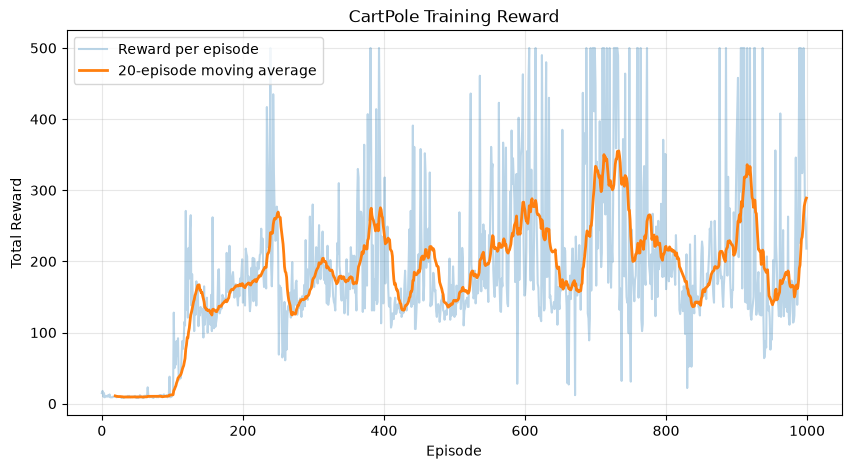

In [22]:
import matplotlib.pyplot as plt
import numpy as np

episodes = [r[0] for r in stats_rewards_list]
rewards = [r[1] for r in stats_rewards_list]

def moving_average(x, window=20):
    return np.convolve(x, np.ones(window)/window, mode='valid')

plt.figure(figsize=(10, 5))
plt.plot(episodes, rewards, alpha=0.3, label='Reward per episode')
if len(rewards) >= 20:
    ma = moving_average(rewards, window=20)
    plt.plot(episodes[19:], ma, label='20-episode moving average', linewidth=2)
plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.title('CartPole Training Reward')
plt.legend()
plt.grid(alpha=0.3)
plt.show()